# FARE Project Notebook

A notebook containing all of the original, primitive FARE solver and plotting code before it was refactored into an object-oriented program.

In [61]:
#Import Modules
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm
from matplotlib.patches import Patch
import matplotlib.colors as colors
import pandas as pd
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator
import ctypes
from scipy import fft
import os
import sys
sys.path.append('/home/tylerhdo/.local/lib/python3.10/site-packages')
import imageio_ffmpeg
import matplotlib
from IPython.display import HTML
from pathlib import Path

# Point matplotlib to the binary
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
print("ffmpeg path set to:", imageio_ffmpeg.get_ffmpeg_exe())

ffmpeg path set to: C:\Users\tydou\anaconda3\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


## FARE Solver

In [64]:
from numba import njit
import numpy as np
from scipy.fft import fft, ifft, fftfreq

# general helper functions which do not require FARE inputs (tridiagonal matrix (Thomas) solvers, interpolation)
# njit is used to let the functions compile directly in C; explicit for loops are otherwise excruciatingly slow compiled in Python

@njit
def thomas_factor(a, b, c): #stores an LU-decomposed matrix given lower, center, and upper diagonal 1D arrays a, b, and c. The benefit of this is that it doesn't need to be done at every iteration.
    n = len(b)
    bp = b.copy()
    cp = c.copy()
    ap = a.copy()
    for i in range(1, n):
        m = ap[i-1] / bp[i-1]
        bp[i] -= m * cp[i-1]
        ap[i-1] = m   # store multiplier (L factor)
    return ap, bp, cp

@njit
def thomas_solve(rhs, ap, bp, cp): # solves the LU-decomposed lower, center, and upper diagonal arrays ap, bp, and cp given a right-hand side.
    nx, n = rhs.shape
    sol = np.empty_like(rhs)
    for i in range(nx):
        # Forward substitution (Ly = rhs)
        y = rhs[i].copy()
        for j in range(1, n):
            y[j] -= ap[j-1] * y[j-1]
        # Back substitution (Ux = y)
        x = np.empty(n, dtype=rhs.dtype)
        x[n-1] = y[n-1] / bp[n-1]
        for j in range(n-2, -1, -1):
            x[j] = (y[j] - cp[j] * x[j+1]) / bp[j]
        sol[i] = x
    return sol

@njit
def thomas_solve_PPE(rhs, ap, bp, cp): # a special thomas solver for the PPE to account for the lack of pressure constraint (which is why the 0th wave-mode is explicitly set to 0)
    nx, n = rhs.shape
    sol = np.empty_like(rhs)
    for i in range(nx):
        if i == 0:           # kx = 0 mode
            sol[i] = 0
            continue
        # Forward substitution
        y = rhs[i].copy()
        for j in range(1, n):
            y[j] -= ap[i, j-1] * y[j-1]
        # Back substitution
        sol[i, n-1] = y[n-1] / bp[i, n-1]
        for j in range(n-2, -1, -1):
            sol[i, j] = (y[j] - cp[i, j] * sol[i, j+1]) / bp[i, j]
    return sol

def zinterp(arr): #interpolates an arbitrary array and returns an interpolated array 1 smaller along z
    return (arr[:,:-1] +arr[:,1:])/2

In [ ]:
# A generalized FARE solver with kwargs for background profiles, forcing, sponge layers, and sponge terrain. 
# Note that for all function inputs (basically all initials/backgrounds/masks), they must be functions of at least x or z so that arrays can be constructed (if they are 0 or constant, you can just do 0*z + c)
def FARE(poti, qvi, # initial rainy potential temperature [K], initial specific humidity [kg/kg], and initial/background horizontal velocity [m/s]
         L, grid, # tuple physical lengths of grid in [m], tuple number of gridpoints including both boundaries (which are equal in the horizontal direction by periodicity) 
         dt, T, s, # time step [s], total simulation time [s], iterations between saves
         pot0, f0, # background potential temperature and intermediate function thereof
         vis_art=None, gam_art=None, RAW_filt=0.01, # vertical 2nd-order viscosity (vis_art), horizontal 4th-order hyperviscosity (gam_art), and RAW filter parameters; if undefined, the first two are later determined based on dt and grid
         u_relax=None, moistening=None, cooling=None, # initial/background horizontal velocity profile [m/s], moistening profile [kg/(kg s)], cooling profile [K/s]
         spongelayer=None, terrainmask=None, # sponge layer and terrain masks; these must be functions of at least x or z (0 where there is no mask, >0 where the mask exists). 
         tauu = 14400, tauM = 50, tauS = 200, # relaxation time of the background horizontal velocity, the terrain mask, and the sponge layer mask, respectively
         Vt = 5.5, # rain terminal velocity (5.5 is a bit high but recommended by the paper)
         explicit_scheme='AB3'): # explicit time scheme; you can choose between Euler Forward (EF), Leapfrog (LF), and Adam-Bashforth 3 (AB3)
    
    #unpack 2d parameters
    Lx, Lz = L
    I, J = grid

    #saved arrays
    N = int(T/dt+1)
    t = np.linspace(0, T, N)
    n_t = np.linspace(0, N-1, N)
    
    #saved solution arrays
    pot_s = np.empty((int((N-1)//s+1),I-1,J))    #potential temperature [K]
    pot_r_s = np.empty((int((N-1)//s+1),I-1,J))  #rainy potential temperature [K]
    qv_s = np.empty((int((N-1)//s+1),I-1,J))     #vapor specific humidity [kg/kg]
    qr_s = np.empty((int((N-1)//s+1),I-1,J))     #rain specific humidity  [kg/kg]
    P_s = np.empty((int((N-1)//s+1),I-1,J))      # Pressure [Pa]
    u_s = np.empty((int((N-1)//s+1),I-1,J))      # Horizontal Velocity  [m/s]
    w_s = np.empty((int((N-1)//s+1),I-1,J))      # Vertical Velocity  [m/s]

    #saved statistic arrays
    C = np.zeros(int((N-1)//s+1))   # Maximum Courant Number
    w_max = np.zeros(int((N-1)//s+1))  # Maximum Vertical Velocity
    temp_max = np.zeros(int((N-1)//s+1)) # Maximum True Temperature
    cons_K = np.zeros(int((N-1)//s+1))  # Average Kinetic Energy
    cons_B = np.zeros(int((N-1)//s+1))  # Average Buoyant Energy
    cons_R = np.zeros(int((N-1)//s+1))  # Average Rain Energy?
    cons_potr = np.zeros(int((N-1)//s+1))   # Average Rainy Potential Temperature (conserved for rain but not water vapor)
    cons_pote = np.zeros(int((N-1)//s+1))   # Average Equivalent Potential Temperature (conserved for water vapor but not rain)
    cons_pot = np.zeros(int((N-1)//s+1))    # Average Potential Temperature (conserved for neither rain nor water vapor)
    cons_qt = np.zeros(int((N-1)//s+1))     # Total Water Content (rain + vapor)
    cons_qv = np.zeros(int((N-1)//s+1))     # Vapor Water Content
    cons_qr = np.zeros(int((N-1)//s+1))     # Rain Water Content

    # Time-level state arrays in Fourier space.
    # (Time, X, Z). Time is organized with 1 = new, 0 = current, -1 = previous, -2 = twice previous.
    P = np.zeros((5,I-1,J+2), dtype=complex) 
    pot = np.zeros((5,I-1,J+2), dtype=complex) 
    qt = np.zeros((5,I-1,J+2), dtype=complex) 
    qr = np.zeros((I-1,J+2), dtype=complex) 
    u = np.zeros((5,I-1,J+2), dtype=complex) 
    w = np.zeros((5,I-1,J+2), dtype=complex) 

    #helpful temporary arrays for implicit-explicit operator splitting
    P_st = np.zeros((I-1,J+2), dtype=complex) 
    u_st = np.zeros((I-1,J+2), dtype=complex) 
    w_st = np.zeros((I-1,J+2), dtype=complex) 
    # RHS time levels use the same convention as the state arrays.
    uRHS = np.zeros((5,I-1,J), dtype=complex)
    wRHS = np.zeros((5,I-1,J-1), dtype=complex)
    potRHS = np.zeros((5,I-1,J), dtype=complex)
    qtRHS = np.zeros((5,I-1,J), dtype=complex)
    
    #Precalculate general parameters:
    dx = Lx/(I-1) 
    dz = Lz/(J-1) 
    kx = 2*np.pi*fftfreq(I-1, d=dx)
    x, z = np.meshgrid(np.linspace(0,Lx-dx,I-1), np.linspace(-dz/2,Lz+3/2*dz,J+2), indexing='ij') 
    zi, zf = 1, J+1 

    #if vis_art and gam_art are set to None (i.e. default), we initialize them to values based on dx, dt, and dz
    if vis_art is None:
        vis_art = 0.01*dz**2/dt
    if gam_art is None:
        gam_art = vis_art*(dx**4)/(np.pi*dz)**2
    
    #Advection-Diffusion Parameters:
    dZ = 2*dz
    dx2 = dx**2
    dz2 = dz**2
    kx2 = kx**2
    Sz = vis_art*dt/(dz**2) 
    G = gam_art*dt/(dx**4) 
    xdamp = np.exp(-gam_art*kx**4*dt)[:, None]
    
    #Physical constants (defined here just in case)
    theta0 = 300 #background temperature
    g0 = 9.8/theta0 #
    CpRd = 1000/287 # Cp/Rd: Cp = specific heat capacity at constant pressure
    LL = 2.5*10**6
    Rv = 462 # water vapor gas constant
    Rd = 287 # dry air gas constant
    p0 = 10**5 #surface pressure
    epsilon0 = 0.6
    qvso = 0.02 # saturation water content
    LCp = LL/1000 # L/Cp: L = latent heat of vaporization for water
    
    #============================================================================================================================================================================================
    #              HELPER FUNCTIONS                  HELPER FUNCTIONS                 HELPER FUNCTIONS                   HELPER FUNCTIONS                   HELPER FUNCTIONS                  
    #============================================================================================================================================================================================

    # ----------------------------------------------  advection helper functions  --------------------------------------------------
    
    mid = (I-1) // 2
    def dea_ifftx(arr): #dealiasing inverse fft, zero-pads the array by 3/2 (1/4 on each side) when transforming to physical space
        pad = np.zeros(((I-1)*3//2, arr.shape[1]), dtype=complex)
        pad[:mid, :] = arr[:mid, :]
        pad[-mid:, :] = arr[-mid:, :]
        return ifft(pad, axis=0).real
    def dea_fftx(arr): #dealiasing fft, takes in a physical array that is 3/2-padded and 
        g = fft(arr, axis=0)
        depad = np.zeros((I-1, arr.shape[1]), dtype=complex)
        depad[:mid, :] = g[:mid, :]    
        depad[-mid:,:] = g[-mid:,:]
        return depad
    def fluz(arr_int, w): #flux form of advection; will cut off vertical by 2
        temps = arr_int*w
        return (temps[:, 1:]-temps[:,:-1])/dz
    def sksym_w(w): #skew symmetric form of advection specifically for w (which is at its own node, and thus uses centered diff dZ)
        w_sq = w**2
        return 1/2*(w[:,1:-1]*(w[:,2:] - w[:,:-2])/dZ + (w_sq[:,2:]-w_sq[:,:-2])/dZ)
    def sksym_u(u, w): #skew symmetric form of advection specifically for u (which is at its own node, and thus uses centered diff dZ)
        u_int = zinterp(u)
        w_int = zinterp(w)
        return 1/2*(fluz(u_int, w) + w_int*(u[:,zi+1:zf+1]-u[:,zi-1:zf-1])/dZ)


    # ----------------------------------------------  implicit tridiagonal matrix callers  --------------------------------------------------

    # dirichlet BC matrix
    apy_diff_dir, bpy_diff_dir, cpy_diff_dir = thomas_factor(-Sz/2*np.ones(zf-zi-2), (Sz+1)*np.ones(zf-zi-1), -Sz/2*np.ones(zf-zi-2))
    
    # neumann BC matrix
    a_neu = -Sz * np.ones(zf-zi+1); a_neu[-1] = -1
    b_neu = np.concatenate([[-1], 2*(Sz+1)*np.ones(zf-zi), [1]])
    c_neu = -Sz * np.ones(zf-zi+1); c_neu[0] = 1
    apy_diff_neu, bpy_diff_neu, cpy_diff_neu = thomas_factor(a_neu, b_neu, c_neu)

    # combination (dir/neu) BC matrix for u if necessary
    a_com = -Sz/2 * np.ones(zf-zi+1); a_com[-1] = -1
    b_com = np.concatenate([[1], (Sz+1)*np.ones(zf-zi), [1]])
    c_com = -Sz/2 * np.ones(zf-zi+1); c_com[0] = -1
    apy_diff_com, bpy_diff_com, cpy_diff_com = thomas_factor(a_com, b_com, c_com)

    def Z_Diffusion_CN_NEU(arr, bg):
        RHS = np.zeros((I-1, zf-zi+2), dtype=complex)
        RHS[:,1:-1] =  Sz*(arr[:,zi-1:zf-1] + arr[:,zi+1:zf+1]) + 2*(1-Sz)*arr[:,zi:zf]
        # Directly enforce physical gradients in the RHS:
        RHS[:,0] = bg[:,0]*dz
        RHS[:,-1] = bg[:,-1]*dz
        solved = thomas_solve(RHS, apy_diff_neu, bpy_diff_neu, cpy_diff_neu)
        return solved            
    
    #parameters for 2nd-order PPE
    apz_PPE, bpz_PPE, cpz_PPE = np.zeros((len(kx), zf-zi+1)), np.zeros((len(kx), zf-zi+2)), np.zeros((len(kx), zf-zi+1))
    for robux in range(len(kx)):
        apz_PPE[robux,:], bpz_PPE[robux,:], cpz_PPE[robux,:] = thomas_factor(np.ones(zf-zi+1), np.concatenate([[-1], (-2-kx2[robux]*dz2)*np.ones(zf-zi), [-1]]), np.ones(zf-zi+1))        

    

    #============================================================================================================================================================================================
    #              INITIAL CONDITIONS                  INITIAL CONDITIONS                 INITIAL CONDITIONS                   INITIAL CONDITIONS                   INITIAL CONDITIONS                  
    #============================================================================================================================================================================================

    
    #Background u, the system will attempt to relax back to this initial on a time scale (default 4 hours)
    if u_relax is None:
        def u_relax(x,z):
            return 0*z
    ubg = fft(u_relax(x,z), axis=0)
    ubg_ph = dea_ifftx(ubg)
    u[0] = ubg
    u_surface = np.mean(ubg[:,0] + u[0,:,1], axis=0) 
    # IMPORTANT: SETTING THE HORIZONTAL VELOCITY [U] LOWER BOUNDARY CONDITIONS
    #  -  If the average background horizontal velocity near the surface is near 0, we use Dirichlet 0 (no slip) B.C. there as a crude parametrization of turbulence. 
    #  -  If the horizontal velocity is significantly greater than 0, we instead use Neumann (free slip) B.C. If we try to use Dirichlet u_surface B.C. here, it will inject unwanted energy into the system.
    if -0.2 <= u_surface <= 0.2:
        u_bc = -1 #corresponds to Dirichlet B.C. (since u is staggered, the ghost node u[:,0] = -u[:,1] such that when interpolated to the true boundary, (u[:,0] + u[:,1])/2 = 0)
    else:
        u_bc = 1 #corresponds to Neumann B.C. (since u is staggered, the ghost node u[:,0] = u[:,1] such that the centered difference over the true boundary (u[:,1] - u[:,0])/2dx = 0 )
    u[0,:,0], u[0,:,J+1] = u_bc*u[0,:,1], u[0,:,J-1] # lower B.C. is either Dir/Neu (see above), upper B.C. is Neumann 0

    #Initial potential temperature
    potil = fft(pot0(x,z), axis=0) 
    DpotilCS = np.zeros((I-1, J+1), dtype=complex)
    pot[0] = fft(poti(x,z), axis=0)
    pot[0,:,0], pot[0,:,J+1] = pot[0,:,1] - DpotilCS[:,0]*dz, pot[0,:,J] + DpotilCS[:,-1]*dz  # lower and upper B.C. are Neumann

    #Initial vapor specific humidity (rain assumed to be 0)
    qvtil = fft(qvi(x,z), axis=0)
    DqvtilCS = (qvtil[:,zi:zf+1]-qvtil[:,zi-1:zf])/dz
    qt[0] = qvtil
    qt[0,:,0], qt[0,:,J+1] = qt[0,:,1] - DqvtilCS[:,0]*dz, qt[0,:,J] + DqvtilCS[:,-1]*dz  # lower and upper B.C. are Neumann

    #Other useful stuff
    f0_field = fft(f0(x,z), axis=0)
    P0 = fft(f0(x,z)**(CpRd), axis=0)
    qvs = fft(qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0)), axis=0)
    qvs_ph = dea_ifftx(qvs)
    #rho0 = p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1) 
    # Boussinesq assumptions require constant rho0; we use the surface value
    rho0 = (p0 / (Rd * theta0)) * np.ones_like(x)

    #interpolated physical background rainy potential temperature and background + saturated vapor specific humidity (needed for buoyancy)
    potil_ph = dea_ifftx(potil)
    pot0_s = pot0(x,z)[:,1:-1]
    potil_int = zinterp(potil_ph)
    qvtil_ph = dea_ifftx(qvtil)
    qvtil_int = zinterp(qvtil_ph)
    qvs_int = zinterp(qvs_ph)
    rho0_int = zinterp(rho0)
    qr = dea_fftx(np.maximum(dea_ifftx(qt[0]) - qvs_ph, 0)) #dealiased

    #by default, when the following kwargs are set to none, we initialize them as zero-functions so that they don't have any effect (this is better than having a ton of if statements later down the line)
    if moistening is None:
        def moistening(x,z):
            return 0*z
    if cooling is None:
        def cooling(x,z):
            return 0*z
    if spongelayer is None:
        def spongelayer(x,z):
            return 0*z
    if terrainmask is None:
        def terrainmask(x,z):
            return 0*z
    
    # Calculate large-scale background forcing profiles in spectral space
    moistenprof = fft(moistening(x, z), axis=0)/2 #divided by two to account for the doubled length
    coolingprof = fft(cooling(x, z), axis=0)/2 #divided by two to account for the doubled length

    #Calculate spongelayer (hereby referred to as boundmask)
    boundmask = fft((dt/tauS)*spongelayer(x,z), axis=0)
    boundmask_ph = dea_ifftx(boundmask)
    boundWmask = fft((dt/tauS)*spongelayer(x, z+dz/2)[:,:-1], axis=0)
    boundWmask_ph = dea_ifftx(boundWmask)

    #Calculate mountain mask (hereby referred to as mountmask)
    mountmask = fft((dt/tauM)*terrainmask(x, z), axis=0)
    mountmask_ph = dea_ifftx(mountmask)
    mountWmask = fft((dt/tauM)*terrainmask(x, z+dz/2)[:,:-1], axis=0)
    mountWmask_ph = dea_ifftx(mountWmask)

    #statistics initialization
    P_phys = ifft(P[0], axis=0).real
    u_phys = ifft(u[0], axis=0).real 
    w_phys = ifft(w[0], axis=0).real
    pot_phys = ifft(pot[0], axis=0).real 
    qt_phys = ifft(qt[0], axis=0).real
    qvs_phys = ifft(qvs, axis=0).real
    qv_phys = np.minimum(qt_phys, qvs_phys)
    qr_phys = np.maximum(qt_phys-qvs_phys,0)
    pot_real = pot_phys+LCp*(qt_phys - qv_phys)
    cons_potr[0] = np.sum(pot_phys[:, 1:-1])*dx*dz 
    cons_pot[0] = np.sum(pot_real[:, 1:-1])*dx*dz
    cons_pote[0] = np.sum(pot_phys[:, 1:-1]+LCp*qv_phys[:, 1:-1])*dx*dz 
    cons_qt[0] = np.sum(qt_phys[:, 1:-1])*dx*dz
    cons_qr[0] = np.sum(qr_phys[:, 1:-1])*dx*dz
    cons_qv[0] = np.sum(qv_phys[:, 1:-1])*dx*dz
    cons_K[0] = 1/2*np.sum(u_phys[:, 1:-1]**2 + w_phys[:, 1:-1]**2)*dx*dz
    cons_B[0] = 0
    cons_R[0] = Vt*g*np.sum(-qr_phys[:, 1:-1] +  (z[:,2:]*qr_phys[:, 2:] - z[:,:-2]*qr_phys[:, :-2])/dZ)
    C[0] = np.max(np.abs(u_phys)*dt/dx + np.abs(w_phys)*dt/dz) 
    w_max[0] = np.max(np.abs(w_phys))
    temp_max[0] = np.max(pot_phys)

    #save initial conditions
    P_s[0], pot_s[0], pot_r_s[0], u_s[0], w_s[0], qv_s[0], qr_s[0] = P_phys[:,1:-1], pot_real[:,1:-1], pot_phys[:,1:-1], u_phys[:,1:-1], w_phys[:,1:-1], qv_phys[:,1:-1], qr_phys[:,1:-1]


    
    #========================================================================================================================================================================================
    #              MAIN SOLVER                  MAIN SOLVER                 MAIN SOLVER                   MAIN SOLVER                   MAIN SOLVER                   MAIN SOLVER
    #========================================================================================================================================================================================

    
    #set overall explicit time scheme (implicit time scheme will always be Crank-Nicolson 2)
    if explicit_scheme == 'EF': #Euler Forward
        sc1, sc2 = N+2, N+2 
    if explicit_scheme == 'LF': #Leapfrog (aka CTCS)
        sc1, sc2 = 2, N+2
    if explicit_scheme == 'AB3': #Adam-Bashforth 3
        sc1, sc2 = 2, 3
    a_AB3, b_AB3, c_AB3 = 23/12, -16/12, 5/12 #ab3 coefficients
    
    m = 1 
    for n in range(1,N):
        # [0] is the current state/RHS, [1] receives the new state, and
        # [-1]/[-2] contain the one- and two-step histories.  The levels
        # are rolled after saving this iteration.
            
        # --------------------------------------------------- CALCULATE ALL NONLINEAR TERMS --------------------------------------------------
        
        #  IFFT all necessary terms to physical space with 3/2-dealiasing (basically all terms related to nonlinear advection and/or piecewise functions)
        u_ph = dea_ifftx(u[0])  
        pot_ph = dea_ifftx(pot[0])
        w_ph = dea_ifftx(w[0,:,:-1]) 
        qt_ph = dea_ifftx(qt[0])
        dudx_ph = dea_ifftx(1j*kx[:, None]*u[0])
        dpotdx_ph = dea_ifftx(1j*kx[:, None]*pot[0])
        dqtdx_ph = dea_ifftx(1j*kx[:, None]*qt[0])
        dwdx_ph = dea_ifftx(1j*kx[:, None]*w[0,:,:-1])
        pot_int = zinterp(pot_ph)
        qt_int = zinterp(qt_ph)
        u_int = zinterp(u_ph[:,1:-1])

        # calculate nonlinear advection in physical space and then fft/de-pad back to fourier space (multiplication in physical space is far cheaper than convolution in spectral)
        f_u = 1/2*1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]**2) + dea_fftx(1/2 * (u_ph[:,1:-1]*dudx_ph[:,1:-1]) + sksym_u(u_ph, w_ph)) #first dea_fftx has the 1/2 flux component, second has the 1/2 advective comp plus vertical skew-symmetric
        f_pot = 1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]*pot_ph[:,1:-1]) + dea_fftx(fluz(pot_int, w_ph))  #flux form treatment
        f_qt = 1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]*qt_ph[:,1:-1]) + dea_fftx(fluz(qt_int, w_ph)) #flux form treatment
        f_w = 1/2*1j*kx[:, None]*dea_fftx(u_int*w_ph[:,1:-1]) + dea_fftx(1/2*(u_int*dwdx_ph[:,1:-1]) + sksym_w(w_ph)) #skew symmetric treatment, same as u

        # calculate buoyancy/water piecewise terms and then fft/de-pad back to foureir space (these must also be calculated in physical space since piecewise is nonlinear)
        potterm = g0*(pot_int - potil_int)
        b_ph = potterm + 9.8*np.where(qt_int<qvs_int, epsilon0*(qt_int-qvtil_int), (LCp/theta0 -1)*(qt_int-qvs_int) + epsilon0*(qvs_int-qvtil_int)) 
        b = dea_fftx(b_ph)
        qr_ph = np.maximum(qt_ph-qvs_ph,0) 
        qr_o = dea_fftx(qr_ph) 
        qr_o[:,0], qr_o[:,J+1] = qr_o[:,1], qr_o[:,J] 
        dqrdz = (qr_o[:,zi+1:zf+1]-qr_o[:,zi-1:zf-1])/dZ
        

        # ------------------------------------------------ ALL EXPLICIT TIME STEPPING ---------------------------------------------------------------------
        
        # gather all forward terms, including the forcing/relaxation terms
        uRHS[0] = dt * (-f_u - 1/tauu * (np.mean(u[0,:,1:-1], axis=0) - ubg[:,1:-1]))  #relaxation to background horizontal velocity
        wRHS[0] = dt * (-f_w + b[:,1:-1])
        qtRHS[0] = dt * (-f_qt + Vt*dqrdz + moistenprof[:, zi:zf])  #forcing moistening term for total specific humidity
        potRHS[0] = dt * (-f_pot - LCp*Vt*dqrdz + coolingprof[:, zi:zf])  #forcing cooling term for rainy potential temperature

        # apply explicit time schemes
        if n < sc1: #Euler Forward
            pot[1,:, zi:zf] = pot[0,:, zi:zf] + potRHS[0]
            qt[1,:, zi:zf] = qt[0,:, zi:zf] + qtRHS[0]
            u_st[:, zi:zf] = (u[0,:, zi:zf] + uRHS[0]) + Sz/2*(u[0,:, zi+1:zf+1] - 2*u[0,:, zi:zf] + u[0,:, zi-1:zf-1])
            w_st[:, zi:zf-1] = (w[0,:, zi:zf-1] + wRHS[0]) + Sz/2*(w[0,:, zi:zf] - 2*w[0,:, zi:zf-1] + w[0,:, zi-1:zf-2])
        elif n < sc2: # Leapfrog
            pot[1,:, zi:zf] = pot[-1,:, zi:zf] + 2*potRHS[0]
            qt[1,:, zi:zf] = qt[-1,:, zi:zf] + 2*qtRHS[0]
            u_st[:, zi:zf] = u[-1,:, zi:zf] + 2*uRHS[0] + Sz*(u[0,:, zi+1:zf+1] - 2*u[0,:, zi:zf] + u[0,:, zi-1:zf-1])
            w_st[:, zi:zf-1] = w[-1,:, zi:zf-1] + 2*wRHS[0] + Sz*(w[0,:, zi:zf] - 2*w[0,:, zi:zf-1] + w[0,:, zi-1:zf-2])
        else:  # AB3
            pot[1,:, zi:zf] = pot[0,:, zi:zf] + a_AB3*potRHS[0] + b_AB3*potRHS[-1] + c_AB3*potRHS[-2]
            qt[1,:, zi:zf] = qt[0,:, zi:zf] + a_AB3*qtRHS[0] + b_AB3*qtRHS[-1] + c_AB3*qtRHS[-2]
            u_st[:, zi:zf] = u[0,:, zi:zf] + a_AB3*uRHS[0] + b_AB3*uRHS[-1] + c_AB3*uRHS[-2] + Sz/2*(u[0,:, zi+1:zf+1] - 2*u[0,:, zi:zf] + u[0,:, zi-1:zf-1])
            w_st[:, zi:zf-1] = w[0,:, zi:zf-1] + a_AB3*wRHS[0] + b_AB3*wRHS[-1] + c_AB3*wRHS[-2] + Sz/2*(w[0,:, zi+1:zf] - 2*w[0,:, zi:zf-1] + w[0,:, zi-1:zf-2])

        # apply Euler Forward pressure gradient force to intermediate velocities (note that we can't use leapfrog or AB3 here because it would leak pressure from previous time steps)
        u_st[:, zi:zf] += - dt*(1/rho0[:, zi:zf])*1j*kx[:, None]*P[0,:,zi:zf] 
        w_st[:, zi:zf-1] += - dt*(1/rho0_int[:, zi:zf-1])*(P[0,:,zi+1:zf]-P[0,:,zi:zf-1])/dz

        #boundary conditions
        pot[1,:,0], pot[1,:,J+1] = pot[1,:,1] - DpotilCS[:,0]*dz, pot[1,:,J] + DpotilCS[:,-1]*dz  #neumann both
        qt[1,:,0], qt[1,:,J+1] = qt[1,:,1] - DqvtilCS[:,0]*dz, qt[1,:,J] + DqvtilCS[:,-1]*dz     #neumann both
        u_st[:,0], u_st[:,J+1] = u_bc*u_st[:,1], u_st[:,J]               #lower dir/neu, upper neumann
        w_st[:,0], w_st[:,J], w_st[:,J+1] = 0, 0, 0                                   # dirichlet both

        
        # ----------------------------------------------------- SEMI-IMPLICIT / EXACT DIFFUSION FOR SCALARS ONLY ---------------------------------------------------------------------

        
        # exact horizontal hyperdiffusion (xdamp) and implicit vertical diffusion second step (Crank-Nicolson 2, only scalar pot/qt terms)
        pot[1] = xdamp*Z_Diffusion_CN_NEU(pot[1], DpotilCS)
        qt[1] = xdamp*Z_Diffusion_CN_NEU(qt[1], DqvtilCS)

        # Re-enforce B.C.s again (just in case yknow)
        pot[1,:,0], pot[1,:,J+1] = pot[1,:,1] - DpotilCS[:,0]*dz, pot[1,:,J] + DpotilCS[:,-1]*dz  #neumann both
        qt[1,:,0], qt[1,:,J+1] = qt[1,:,1] - DqvtilCS[:,0]*dz, qt[1,:,J] + DqvtilCS[:,-1]*dz    # neumann both

        
        # -------------------------------------------- SEMI-IMPLICIT INCREMENTAL PRESSURE POISSON SOLVER FOR P, U, and W ---------------------------------------------------------------------
        
        P_RHS = np.zeros((I-1, J+2), dtype=complex)
        P_RHS[:, 1:-1] = rho0[:,1:-1]*dz2/dt*(1j*kx[:, None]*u_st[:,zi:zf]+(w_st[:,zi:zf]-w_st[:,zi-1:zf-1])/dz) 
        P_RHS[0, :] = 0.0 
        
        P_st = thomas_solve_PPE(P_RHS, apz_PPE, bpz_PPE, cpz_PPE) #solving the PPE for the intermediate pressure correction
        #  pressure correction Neumann BC for all kx
        P_st[:, 0], P_st[:,J+1] = P_st[:,1], P_st[:,J]
        P_st[0, zi] = 0.0
        #something to keep the 0th wave mode consistent with PPE (otherwise it'll just be all zeros regardless of height)
        increments = w_st[0, zi:zf-1] * rho0_int[0, zi:zf-1] * dz / dt
        P_st[0, zi+1:zf] = P_st[0, zi] + np.cumsum(increments)
        # Re-apply Neumann for kx=0 mode specifically
        P_st[0, 0] = P_st[0, zi]
        P_st[0, J+1] = P_st[0, zf-1]

        # update velocities with semi-implicit pressure + crank-nicolson vertical diffusion + exact horizontal hyperdiffusion
        RHS_u_solver = u_st + dt*(-1/rho0 * 1j*kx[:, None]*P_st)
        RHS_u_solver[:,0], RHS_u_solver[:,-1] = 0, 0
        u[1] = xdamp*thomas_solve(RHS_u_solver, apy_diff_com, bpy_diff_com, cpy_diff_com)
        RHS_w_solver = w_st[:, zi:zf-1] + dt*(-1/rho0_int[:, zi:zf-1] * (P_st[:,zi+1:zf]-P_st[:,zi:zf-1])/dz)
        w[1,:, zi:zf-1] = xdamp*thomas_solve(RHS_w_solver, apy_diff_dir, bpy_diff_dir, cpy_diff_dir)
        
        # re-enforce BCs
        u[1,:,0], u[1,:,J+1] = u_bc*u[1,:,1], u[1,:,J] 
        w[1,:,0], w[1,:,J], w[1,:,J+1] = 0, 0, 0   
        
        #final pressure update
        P[1] = P[0] + P_st
        P[1,:, 0], P[1,:,J+1] = P[1,:,1] , P[1,:,J] 


        # --------------------------------------------------------  SPONGES AND FILTERS --------------------------------------------------------------------

        # Time-dependent ramp for masks
        # makes it so that the terrain and sponge layer aren't immediately forced into being at the start of the simulation, and instead take ~2 hours to reach their maximum forcing, which is less than the time it takes for physically realistic solutions to start appearing
        tau_ramp = 7200
        t_cur = n * dt
        ramp = 1 if t_cur >= tau_ramp else np.sin(np.pi/2 * (t_cur/tau_ramp))**2
        current_mask_ph = boundmask_ph + mountmask_ph * ramp
        current_Wmask_ph = boundWmask_ph + mountWmask_ph * ramp

        #apply exact sponge layers + mountain mask to scalars
        qt_ph2 = dea_ifftx(qt[1])
        pot_ph2 = dea_ifftx(pot[1])
        qt[1,:, zi:zf] = dea_fftx(((qt_ph2 + boundmask_ph*qvtil_ph)/(1 + boundmask_ph))[:, 1:-1])
        pot[1,:, zi:zf] = dea_fftx(((pot_ph2 + boundmask_ph*potil_ph)/(1 + boundmask_ph))[:, 1:-1])
        
        #apply exact sponge layers + mountain mask to velocities
        u_clean_ph = dea_ifftx(u[1])
        w_clean_ph = dea_ifftx(w[1,:,:-1])
        u[1,:, zi:zf] = dea_fftx(((u_clean_ph + boundmask_ph*ubg_ph)/(1 + current_mask_ph))[:, 1:-1])
        w[1,:, zi:zf-1] = dea_fftx((w_clean_ph/(1 + current_Wmask_ph))[:, 1:-1])
        
        # re-enforce BCs again
        pot[1,:,0], pot[1,:,J+1] = pot[1,:,1] - DpotilCS[:,0]*dz, pot[1,:,J] + DpotilCS[:,-1]*dz  #neumann both
        qt[1,:,0], qt[1,:,J+1] = qt[1,:,1] - DqvtilCS[:,0]*dz, qt[1,:,J] + DqvtilCS[:,-1]*dz    # neumann both
        u[1,:,0], u[1,:,J+1] = u_bc*u[1,:,1], u[1,:,J]                           #lower dir/neu, upper neumann
        w[1,:,0], w[1,:,J], w[1,:,J+1] = 0, 0, 0                                           # dirichlet both
        
        # RAW Filter to damp the computational mode if using Leapfrog
        if sc1 <= n < sc2: 
            u[0] += RAW_filt*(u[-1] - 2*u[0] + u[1] - 0.5*(u[1]-u[-1]))
            w[0] += RAW_filt*(w[-1] - 2*w[0] + w[1] - 0.5*(w[1]-w[-1]))
            pot[0] += RAW_filt*(pot[-1] - 2*pot[0] + pot[1] - 0.5*(pot[1]-pot[-1]))
            qt[0] += RAW_filt*(qt[-1] - 2*qt[0] + qt[1] - 0.5*(qt[1]-qt[-1]))


        # ---------------------------------------------  SAVING THE SOLUTION --------------------------------------------------------------------


        if n % s == 0: # save all solutions and statistics every s iterations
            P_phys = ifft(P[1], axis=0).real
            u_phys = ifft(u[1], axis=0).real 
            w_phys = ifft(w[1], axis=0).real
            pot_phys = ifft(pot[1], axis=0).real 
            qt_phys = ifft(qt[1], axis=0).real
            qvs_phys = ifft(qvs, axis=0).real
            qv_phys = np.minimum(qt_phys, qvs_phys)
            qr_phys = np.maximum(qt_phys-qvs_phys,0)
            pot_real = pot_phys+LCp*(qt_phys - qv_phys)
            b_phys = ifft(b, axis=0).real
            cons_potr[m] = np.sum(pot_phys[:, 1:-1])*dx*dz 
            cons_pote[m] = np.sum(pot_phys[:, 1:-1]+LCp*qv_phys[:, 1:-1])*dx*dz
            cons_pot[m] = np.sum(pot_real[:, 1:-1])*dx*dz
            cons_qt[m] = np.sum(qt_phys[:, 1:-1])*dx*dz
            cons_qr[m] = np.sum(qr_phys[:, 1:-1])*dx*dz
            cons_qv[m] = np.sum(qv_phys[:, 1:-1])*dx*dz
            cons_K[m] = 1/2*np.sum(u_phys[:, 1:-1]**2 + w_phys[:, 1:-1]**2)*dx*dz
            cons_B[m] = -np.sum(b_phys[:, 1:-1])*dx*dz
            cons_R[m] = Vt*g*np.sum(-qr_phys[:, 1:-1] +  (z[:,2:]*qr_phys[:, 2:] - z[:,:-2]*qr_phys[:, :-2])/dZ)
            C[m] = np.max(np.abs(u_phys)*dt/dx + np.abs(w_phys)*dt/dz)
            w_max[m] = np.max(np.abs(w_phys))
            temp_max[m] = np.max(pot_phys)

            P_s[m], pot_s[m], pot_r_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P_phys[:,1:-1], pot_real[:,1:-1], pot_phys[:,1:-1], u_phys[:,1:-1], w_phys[:,1:-1], qv_phys[:,1:-1], qr_phys[:,1:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1

        # Roll state levels without allocating/copying separate history arrays.
        # Slot [2] stages the move so that the current and prior values are
        # not overwritten before they reach [-1] and [-2].
        for field in (P, pot, u, w, qt):
            field[2] = field[-1]
            field[-2] = field[2]
            field[2] = field[0]
            field[-1] = field[2]
            field[0] = field[1]
        for rhs in (uRHS, wRHS, potRHS, qtRHS):
            rhs[2] = rhs[-1]
            rhs[-2] = rhs[2]
            rhs[2] = rhs[0]
            rhs[-1] = rhs[2]

    t_s = t[::s]
    x = x[:,1:-1] 
    z = z[:,1:-1]

    return n_t, t_s, cons_potr,cons_pote, cons_pot, cons_qt, cons_qr,cons_qv, cons_K,cons_B, cons_R, C, w_max, temp_max, x, z, P_s, pot_s, pot_r_s, u_s, w_s, qv_s, qr_s, pot0_s

## Simulations

### RUN THESE BEFORE DOING ANY SIMULATIONS - Output Arrays, Parameters, and Environmental Moistening/Cooling Profiles

In [68]:
#create empty arrays for solution storage
trials = 3
l, U, C, K, t_s, pot0_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
P_s, pot_s, u_s, w_s, pot_r_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
w_max, temp_max, x, z = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_potr,cons_pote,cons_qt, qv_s, qr_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_qr, cons_qv, cons_pot, cons_K, cons_B, cons_R = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)

In [70]:
#FARE terms (all in SI units, q is in g/kg)
g=9.8
theta0 = 300
rho0 = 1.2
B = 0.003
cp = 1000
LL = 2.5*10**6
Rd = 287
Rv = 462
DALR = g/cp
CpRd = cp/Rd
p0 = 10**5
epsilon0 = 0.6
eso = 3500
qvso = 0.02
LCp = LL/cp


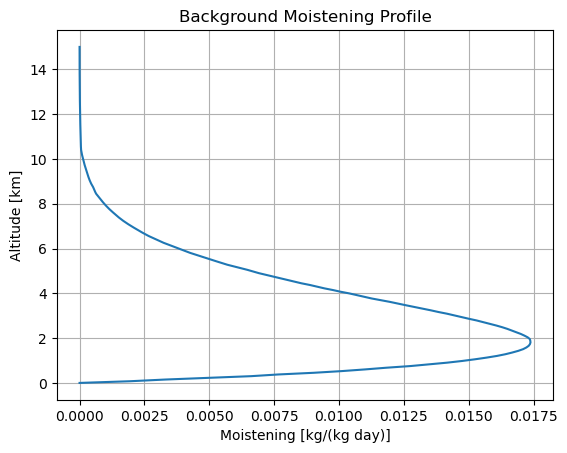

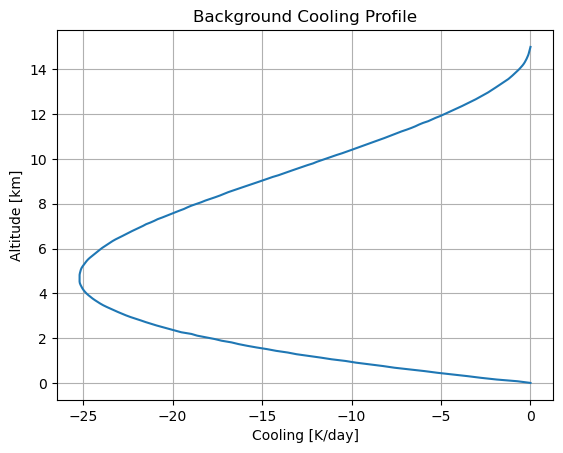

In [72]:
# load in moistening and cooling environmental profiles
# these were obtained by very carefully scrutinizing the profiles shown in the Minimal Models for Moist Precipitating Convection paper
moisturedata = pd.read_csv('Moisture - Moisture.csv', delimiter=',')
coolingdata = pd.read_csv('Cooling - Cooling.csv', delimiter=',')
moisturedata = moisturedata.drop_duplicates().sort_values(by='y')
coolingdata = coolingdata.drop_duplicates().sort_values(by='y')
zmoist = moisturedata['y'].to_numpy()
moistz = moisturedata['x'].to_numpy()
zcool = coolingdata['y'].to_numpy()
coolz = coolingdata['x'].to_numpy()

# moistening/cooling functions (using Pchip interpolator). These will be used for the actual computation.
def moistrate(x,z):
    moistrat = (PchipInterpolator(zmoist, moistz)(z/1000))/(86400*1000)
    return moistrat
def coolrate(x,z):
    coolrat =  (PchipInterpolator(zcool, coolz)(z/1000))/(86400)
    return coolrat
# moistening/cooling functions (using Pchip interpolator). These are just for visualization, since they are only functions of z.
def moistlooker(z):
    moistrat = (PchipInterpolator(zmoist, moistz)(z/1000))/(86400*1000)
    return moistrat 
def coollooker(z):
    coolrat =  (PchipInterpolator(zcool, coolz)(z/1000))/(86400)
    return coolrat

ztau = np.linspace(0,15000, 200)
moist_int = 1/15000*np.trapz(moistlooker(ztau), ztau)
cool_int  = 1/15000*np.trapz(coollooker(ztau), ztau)

plt.plot(moistlooker(ztau)*86400, ztau/1000)
plt.xlabel('Moistening [kg/(kg day)]')
plt.ylabel('Altitude [km]')
plt.title('Background Moistening Profile')
plt.grid()
plt.show()

plt.plot(coollooker(ztau)*86400, ztau/1000)
plt.xlabel('Cooling [K/day]')
plt.ylabel('Altitude [km]')
plt.title('Background Cooling Profile')
plt.grid()
plt.show()

### Shallow Convection

In [74]:
#input functions

def qvi(x,z):
    qvtil = 0.018/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))
    return qvtil

def pot0(x, z):
    return theta0+B*z

def poti(x, z):
    poti = pot0(x, z)
    x_mask = np.zeros(poti.shape[0], dtype=bool)
    x_mask[15:-15] = True
    z_mask = z < 2000
    combined_mask = (x_mask[:, np.newaxis]) & z_mask
    noise_size = np.sum(combined_mask)
    poti[combined_mask] += np.random.uniform(low=-0.1, high=0.1, size=noise_size)
    return poti

def f0(x, z):
    return 1 - DALR/B*np.log1p(B*z/theta0)

def P0(x, z): #divided by p0 = 10^5
    return f0(x,z)**(CpRd)

def rho0(x, z):
    return np.mean(p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1))

def qvs(x, z):
    return qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))

In [76]:
#computational parameters
L = [256000, 15000]
grid = [[257,100],[501, 201],[451,301],[601,401]]
dt = 2.2 #time step in seconds
T = 79200 #a lot of times
s = 20

for i in range(0,1):
    outputz = FARE(poti, qvi, L, grid[i], dt, T, s, pot0, f0, moistening=moistrate, cooling=coolrate, Vt = 5, explicit_scheme='AB3')
    n_t, t_s[i], cons_potr[i], cons_pote[i], cons_pot[i], cons_qt[i], cons_qr[i], cons_qv[i], cons_K[i],cons_B[i], cons_R[i], C[i], w_max[i], temp_max[i], x[i], z[i], P_s[i], pot_s[i], pot_r_s[i], u_s[i], w_s[i], qv_s[i], qr_s[i], pot0_s[i] = outputz
    print(f' Simulation {i+1} is complete!')

 Save 1800! Simulation 1 is complete!


### Squall Line

In [420]:
#input functions

def qvi(x,z):
    qvtil = 0.018/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))
    return qvtil

def pot0(x, z):
    return theta0+B*z

def poti(x, z):
    poti = pot0(x, z)
    x_mask = np.zeros(poti.shape[0], dtype=bool)
    x_mask[30:-30] = True
    z_mask = z < 2000
    combined_mask = (x_mask[:, np.newaxis]) & z_mask
    noise_size = np.sum(combined_mask)
    poti[combined_mask] += np.random.uniform(low=-0.1, high=0.1, size=noise_size)
    return poti

def f0(x, z):
    return 1 - DALR/B*np.log1p(B*z/theta0)

def P0(x, z): #divided by p0 = 10^5
    return f0(x,z)**(CpRd)

def rho0(x, z):
    return p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1)

def qvs(x, z):
    return qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))

def vertical_shear(x,z): 
    H0 = 12000
    a = 11.11
    return np.where(z<H0, a*(np.cos(np.pi*z/H0) - np.cos(2*np.pi*z/H0)), -2*a)

In [422]:
#input parameters
L = [256000, 15000]
grid = [[257,100],[501, 201],[451,301],[601,401]]
dt = 2.2 #time step in seconds
T = 148500 #a lot of times
s = 20

for i in range(0,1):
    outputz = FARE(poti, qvi, L, grid[i], dt, T, s, pot0, f0, u_relax = vertical_shear, moistening=moistrate, cooling=coolrate, Vt = 5, explicit_scheme='AB3')
    n_t, t_s[i], cons_potr[i], cons_pote[i], cons_pot[i], cons_qt[i], cons_qr[i], cons_qv[i], cons_K[i],cons_B[i], cons_R[i], C[i], w_max[i], temp_max[i], x[i], z[i], P_s[i], pot_s[i], pot_r_s[i], u_s[i], w_s[i], qv_s[i], qr_s[i], pot0_s[i] = outputz
    print(f' Simulation {i+1} is complete!')

 Save 1838!

C:\Users\tydou\AppData\Local\Temp\ipykernel_34828\478211028.py:234: RuntimeWarning: overflow encountered in square
  f_u = 1/2*1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]**2) + dea_fftx(1/2 * (u_ph[:,1:-1]*dudx_ph[:,1:-1]) + sksym_u(u_ph, w_ph)) #first dea_fftx has the 1/2 flux component, second has the 1/2 advective comp plus vertical skew-symmetric
C:\Users\tydou\AppData\Local\Temp\ipykernel_34828\478211028.py:234: RuntimeWarning: invalid value encountered in multiply
  f_u = 1/2*1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]**2) + dea_fftx(1/2 * (u_ph[:,1:-1]*dudx_ph[:,1:-1]) + sksym_u(u_ph, w_ph)) #first dea_fftx has the 1/2 flux component, second has the 1/2 advective comp plus vertical skew-symmetric
C:\Users\tydou\AppData\Local\Temp\ipykernel_34828\478211028.py:234: RuntimeWarning: overflow encountered in multiply
  f_u = 1/2*1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]**2) + dea_fftx(1/2 * (u_ph[:,1:-1]*dudx_ph[:,1:-1]) + sksym_u(u_ph, w_ph)) #first dea_fftx has the 1/2 flux component, second has the 1

 Save 3375! Simulation 1 is complete!


### Atmospherc River

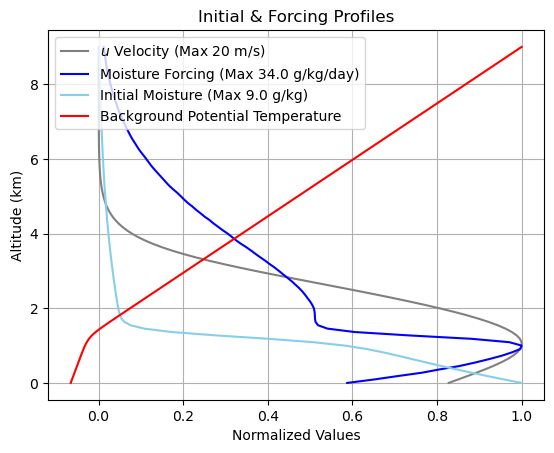

In [580]:
# input functions

def pot0(x, z):
    theta_surf = 288.0  
    gamma_mbl = 0.001   
    gamma_trop = 0.004  
    z_inv = 1250.0       
    width = 200.0       
    smooth_step = width * np.log(np.cosh((z - z_inv) / width)) - width * np.log(np.cosh(-z_inv / width))
    return theta_surf + ((gamma_mbl + gamma_trop) / 2.0) * z + ((gamma_trop - gamma_mbl) / 2.0) * smooth_step

def poti(x, z):
    poti = pot0(x, z)
    x_mask = np.zeros(poti.shape[0], dtype=bool)
    x_mask[30:-30] = True
    z_mask = z < 2000
    combined_mask = (x_mask[:, np.newaxis]) & z_mask
    noise_size = np.sum(combined_mask)
    poti[combined_mask] += np.random.uniform(low=-0.02, high=0.02, size=noise_size)
    return poti

from scipy.integrate import cumulative_trapezoid

def f0(x, z):
    # Numerically integrates the hydrostatic equation
    theta = pot0(x, z)
    integrand = -DALR / theta
    integral = cumulative_trapezoid(integrand, z, axis=-1, initial=0)
    return 1.0 + integral

def P0(x, z): #divided by p0 = 10^5
    return f0(x,z)**(CpRd)

def rho0(x, z):
    return p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1)

def qvs(x, z):
    return qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))

def qvi(x, z):
    qvs_initial = qvs(x, z)
    RH = 0.10 + 0.85 * 0.5 * (1 - np.tanh((z - 1250) / 200.0))
    return qvs_initial * RH

def moistrate2(x, z):
    moist_bg = (PchipInterpolator(zmoist, moistz)(z/1000)) / (86400 * 1000)
    x_coast = 100000
    ramp = 10000
    xmask = 0.5 * (1 + np.tanh((x_coast - x) / ramp))
    z_inv = 1250.0   
    z_sharp = 160.0 
    zmask = 0.5 * (1 - np.tanh((z - z_inv) / z_sharp))
    marine_mag = 20 / (86400 * 1000) #g/kg day -> #g/g s
    marine_forcing = marine_mag * xmask * zmask
    return moist_bg + marine_forcing

def coolrate2(x,z):
    coolrat =  (PchipInterpolator(zcool, coolz)(z/1000))/(86400)
    return coolrat

def surface_jet(x, z):
    U_base = 12.0  
    base_wind = U_base * 0.5 * (1 - np.tanh((z - 3000.0) / 1000.0))
    U_jet = 8.0 
    z_jet = 1100
    h_jet = 1000
    jet_core = U_jet * np.exp(-((z - z_jet)**2) / (2 * h_jet**2))
    return base_wind + jet_core

def mountainmask(x, z):
    x_mount = 130000.0
    sigma = 15000.0  
    h = 1500.0 * np.exp(-((x - x_mount)**2) / (2.0 * sigma**2))
    z_sigma = 100.0 + 100.0 * (h / 1250.0) 
    vertical_mask = 0.5 * (1 - np.tanh((z - h) / z_sigma))
    horizontal_envelope = np.tanh(h / 50.0) 
    raw_mask = vertical_mask * horizontal_envelope
    return np.where(raw_mask > 0.02, raw_mask, 0.0)

def boundarymask(x, z):
    w = 15000  
    Lx = 256000
    leftmask = np.where(x < w, 0.5 * (1 + np.cos(np.pi * x / w)), 0.0)
    rightmask = np.where(x > (Lx - w), 0.5 * (1 + np.cos(np.pi*(Lx - x)/w)), 0.0)
    topmask = 0.5 * (1 + np.tanh((z-9000)/1000))
    return 1 - (1-leftmask)*(1-rightmask)*(1-topmask)

def mountainshape(x):
    x_mount = 130000
    sigma = 15000.0  
    h = 1500.0 * np.exp(-((x - x_mount)**2) / (2.0 * sigma**2))
    return h

ztestil = np.linspace(0, 9000, 100)

plt.plot(u_init(0,ztestil)/np.max(u_init(0,ztestil)),ztestil/1000, color='grey', label='$u$ Velocity (Max 20 m/s)')
plt.plot(moistrate(0,ztestil)/np.max(moistrate(0,ztestil)),ztestil/1000, color='blue', label=f'Moisture Forcing (Max {np.max(moistrate(0,ztestil))*1000*86400:.1f} g/kg/day)')
plt.plot(qvi(0,ztestil)/np.max(qvi(0,ztestil)), ztestil/1000, color='skyblue', label=f'Initial Moisture (Max {np.max(qvi(0,ztestil))*1000:.1f} g/kg)')
plt.plot((pot0(0,ztestil)-290)/(np.max(pot0(0,ztestil))-290), ztestil/1000, color='red', label=f'Background Potential Temperature')
plt.legend(loc='upper left')
plt.xlabel('Normalized Values')
plt.ylabel('Altitude (km)')
plt.title('Initial & Forcing Profiles')
plt.grid()
plt.savefig('Mount_Profils.png', dpi=200)

xtestil = np.linspace(0,256000, 100)

In [558]:
#input parameters
L = [256000, 12000]
grid = [[257,200],[501, 201],[451,301],[601,401]]
dt = 1.1  #time step in seconds
T = 80000 #a lot of times
s = 40

for i in range(0,1):
    outputz = FARE(poti, qvi, L, grid[i], dt, T, s, pot0, f0, u_relax=surface_jet, moistening=moistrate2, cooling=coolrate2, spongelayer=boundarymask, terrainmask=mountainmask, Vt = 6, explicit_scheme='AB3')
    n_t, t_s[i], cons_potr[i], cons_pote[i], cons_pot[i], cons_qt[i], cons_qr[i], cons_qv[i], cons_K[i],cons_B[i], cons_R[i], C[i], w_max[i], temp_max[i], x[i], z[i], P_s[i], pot_s[i], pot_r_s[i], u_s[i], w_s[i], qv_s[i], qr_s[i], pot0_s[i] = outputz
    print(f' Simulation {i+1} is complete!')

 Save 1818! Simulation 1 is complete!


## Animations

#### Temperature and Velocity Quiver Field

Simulation 1 is complete!


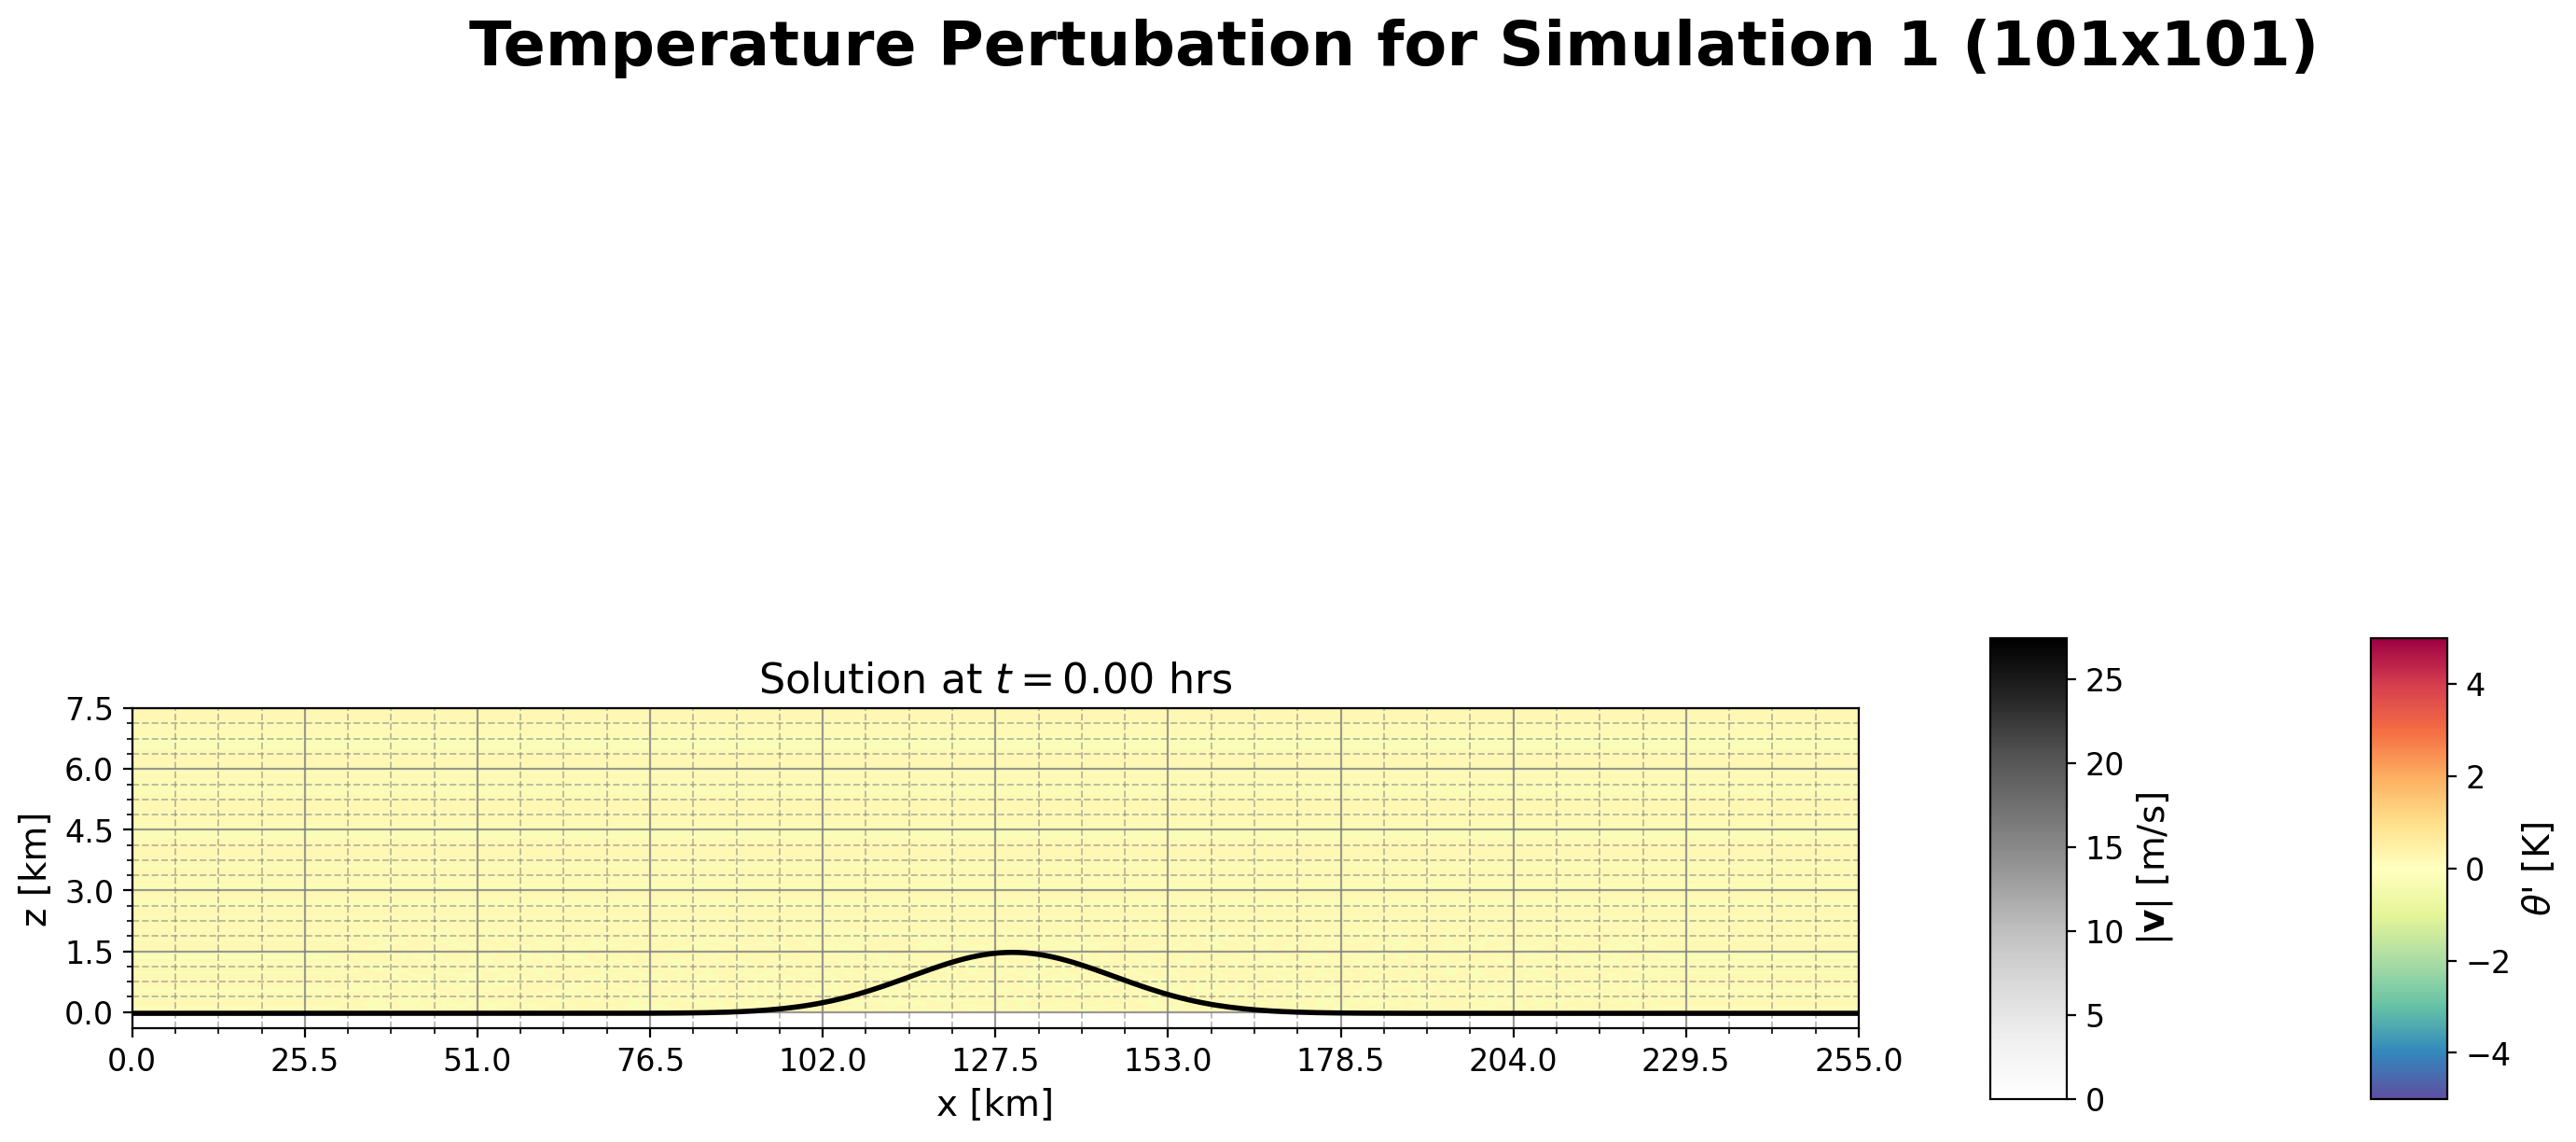

In [562]:
#temperature and velocity pertubations from means at that altitude
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from pathlib import Path

#prime field
vmin = -5
vmax = 5
z_cut = 125
sim = ["(101x101)", "(201x201)","(401x401)"]

for i in range(0,1):
    Quantity = pot_s[i][:, :, :z_cut]
    x1, y1 = x[i][:, :z_cut], z[i][:, :z_cut]

    #x_line = x1[:,0]
    #h = mountainshape(x_line) 
        
    # --- Interpolate staggered w to u nodes (cell centers) ---
    # w_s[i] shape is (time, Nx, Nz), representing the top faces.
    # prepend the chopped 0th boundary node (bottom wall, w=0).
    w_padded = np.zeros((w_s[i][:,:, :z_cut].shape[0], w_s[i][:,:, :z_cut].shape[1], w_s[i][:,:, :z_cut].shape[2] + 1))
    w_padded[:, :, 1:] = w_s[i][:,:, :z_cut]
    w_interp = (w_padded[:, :, :-1] + w_padded[:, :, 1:]) / 2.0
    # ---------------------------------------------------------

    # ---------------- QUIVER SETUP ----------------
    # calculate global max speed across entire simulation for stable color/scaling
    max_spd = np.max(np.sqrt((u_s[i][:2401,:, :z_cut]-np.mean(u_s[i][:2401,:, :z_cut],axis=1, keepdims=True))**2 + w_interp[:2401]**2)) * 0.8
    norm_spd = colors.Normalize(vmin=0, vmax=max_spd)
    
    # dynamically determine subsampling for a wide aspect ratio
    # ~35 arrows horizontal and ~12 arrows vertical
    skip_x = max(1, x1.shape[0] // 35)
    skip_z = max(1, x1.shape[1] // 10)
    
    # tuning parameter for arrow length. DECREASE this number to make arrows longer.
    # adjust this until the max speed arrow just touches the next grid point.
    q_scale = max_spd * 15 
    # ----------------------------------------------

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)

    # Filled and line contours (Temperature)
    cf = ax.contourf(x1, y1, Quantity[0]-np.mean(Quantity[0], axis=0, keepdims=True), levels=np.linspace(vmin, vmax, 25), cmap='Spectral_r', vmin=vmin, vmax=vmax, extend='both') 
    ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

    u_c = u_s[i][0, :, :z_cut]-np.mean(u_s[i][0, :, :z_cut],axis=0, keepdims=True)
    w_c = w_interp[0]
    spd = np.sqrt(u_c**2 + w_c**2)
    
    # --- Cap max arrow length to prevent overlapping ---
    spd_limit = max_spd * 0.4  # Cap visual length at 75% of max speed (tune as needed)
    spd_capped = np.minimum(spd, spd_limit)
    u_plot = (u_c / (spd + 1e-12)) * spd_capped
    w_plot = (w_c / (spd + 1e-12)) * spd_capped
    
    Vel = ax.quiver(x1[::skip_x, ::skip_z], y1[::skip_x, ::skip_z], 
                    u_plot[::skip_x, ::skip_z], w_plot[::skip_x, ::skip_z], 
                    spd[::skip_x, ::skip_z], # Still use raw spd for true color!
                    cmap='Greys', norm=norm_spd, scale=q_scale, zorder=10,
                    width=0.002, headwidth=4, headlength=4, headaxislength=3, minlength=0)

    # Labels and formatting
    ax.set_title(r"Solution at $t = $"+ f"{t_s[i][0]:.3f} sec", fontsize=16, y=1)
    plt.suptitle(f'Temperature Pertubation for Simulation {i+1} '+sim[i], fontsize=24, fontweight='bold', y=0.98)
    ax.set_xlabel('x [km]', fontsize=12)
    ax.set_ylabel('z [km]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_aspect(6, anchor='C')

    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
    ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

    # Temperature Colorbar
    norm_t = colors.Normalize(vmin=vmin, vmax=vmax)
    mappable_t = cm.ScalarMappable(norm=norm_t, cmap='Spectral_r')
    mappable_t.set_array([])
    cbar = fig.colorbar(mappable_t, ax=ax, shrink=0.3, aspect=6, pad=0.02)
    cbar.set_label(r"$\theta$' [K]", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    
    # Velocity Colorbar
    cbar2 = fig.colorbar(Vel, ax=ax, shrink=0.3, aspect=6, pad=0.06)
    cbar2.set_label(r'$|\mathbf{v}|$ [m/s]', fontsize=14)
    cbar2.ax.tick_params(labelsize=12)
    
    fig.tight_layout()

    def update(n):
        ax.clear()

        # Filled and black line contours
        cf = ax.contourf(x1, y1, Quantity[n]-np.mean(Quantity[n], axis=0, keepdims=True), levels=np.linspace(vmin, vmax, 25), cmap='Spectral_r', vmin=vmin, vmax=vmax, extend='both')
        ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

        # Quiver (Velocity) - Must be re-drawn each frame because ax.clear() removes it
        u_c = u_s[i][n, :, :z_cut]-np.mean(u_s[i][n, :, :z_cut],axis=0, keepdims=True)
        w_c = w_interp[n]
        spd = np.sqrt(u_c**2 + w_c**2)
        
        # --- Cap max arrow length ---
        spd_capped = np.minimum(spd, spd_limit)
        u_plot = (u_c / (spd + 1e-12)) * spd_capped
        w_plot = (w_c / (spd + 1e-12)) * spd_capped
        
        Vel = ax.quiver(x1[::skip_x, ::skip_z], y1[::skip_x, ::skip_z], 
                        u_plot[::skip_x, ::skip_z], w_plot[::skip_x, ::skip_z], 
                        spd[::skip_x, ::skip_z], 
                        cmap='Greys', norm=norm_spd, scale=q_scale, zorder=10,
                        width=0.002, headwidth=4, headlength=4, headaxislength=3, minlength=0)

        # Title and labels
        ax.set_title(r"Solution at $t = $"+ f"{t_s[i][n]/3600:.2f} hrs", fontsize=16, y=1)
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [km]', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect(6, anchor='C')

        # Ticks and grid
        ax.minorticks_on()
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
        ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
        ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
        ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
        ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

        return cf, Vel

    # Create and save animation
    ani = FuncAnimation(fig, update, frames=range(0, 1801), interval=50, blit=False) #

    filename = f"Mount_{i+1}_Temperature.mp4"
    ani.save(filename, writer='ffmpeg', fps=20)
    print(f'Simulation {i+1} is complete!')

    # Display in notebook
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(filename).as_posix()}" type="video/mp4">
      Your browser does not support the video tag.</video>"""))

#### Water Content Fields

Simulation 1 is complete!


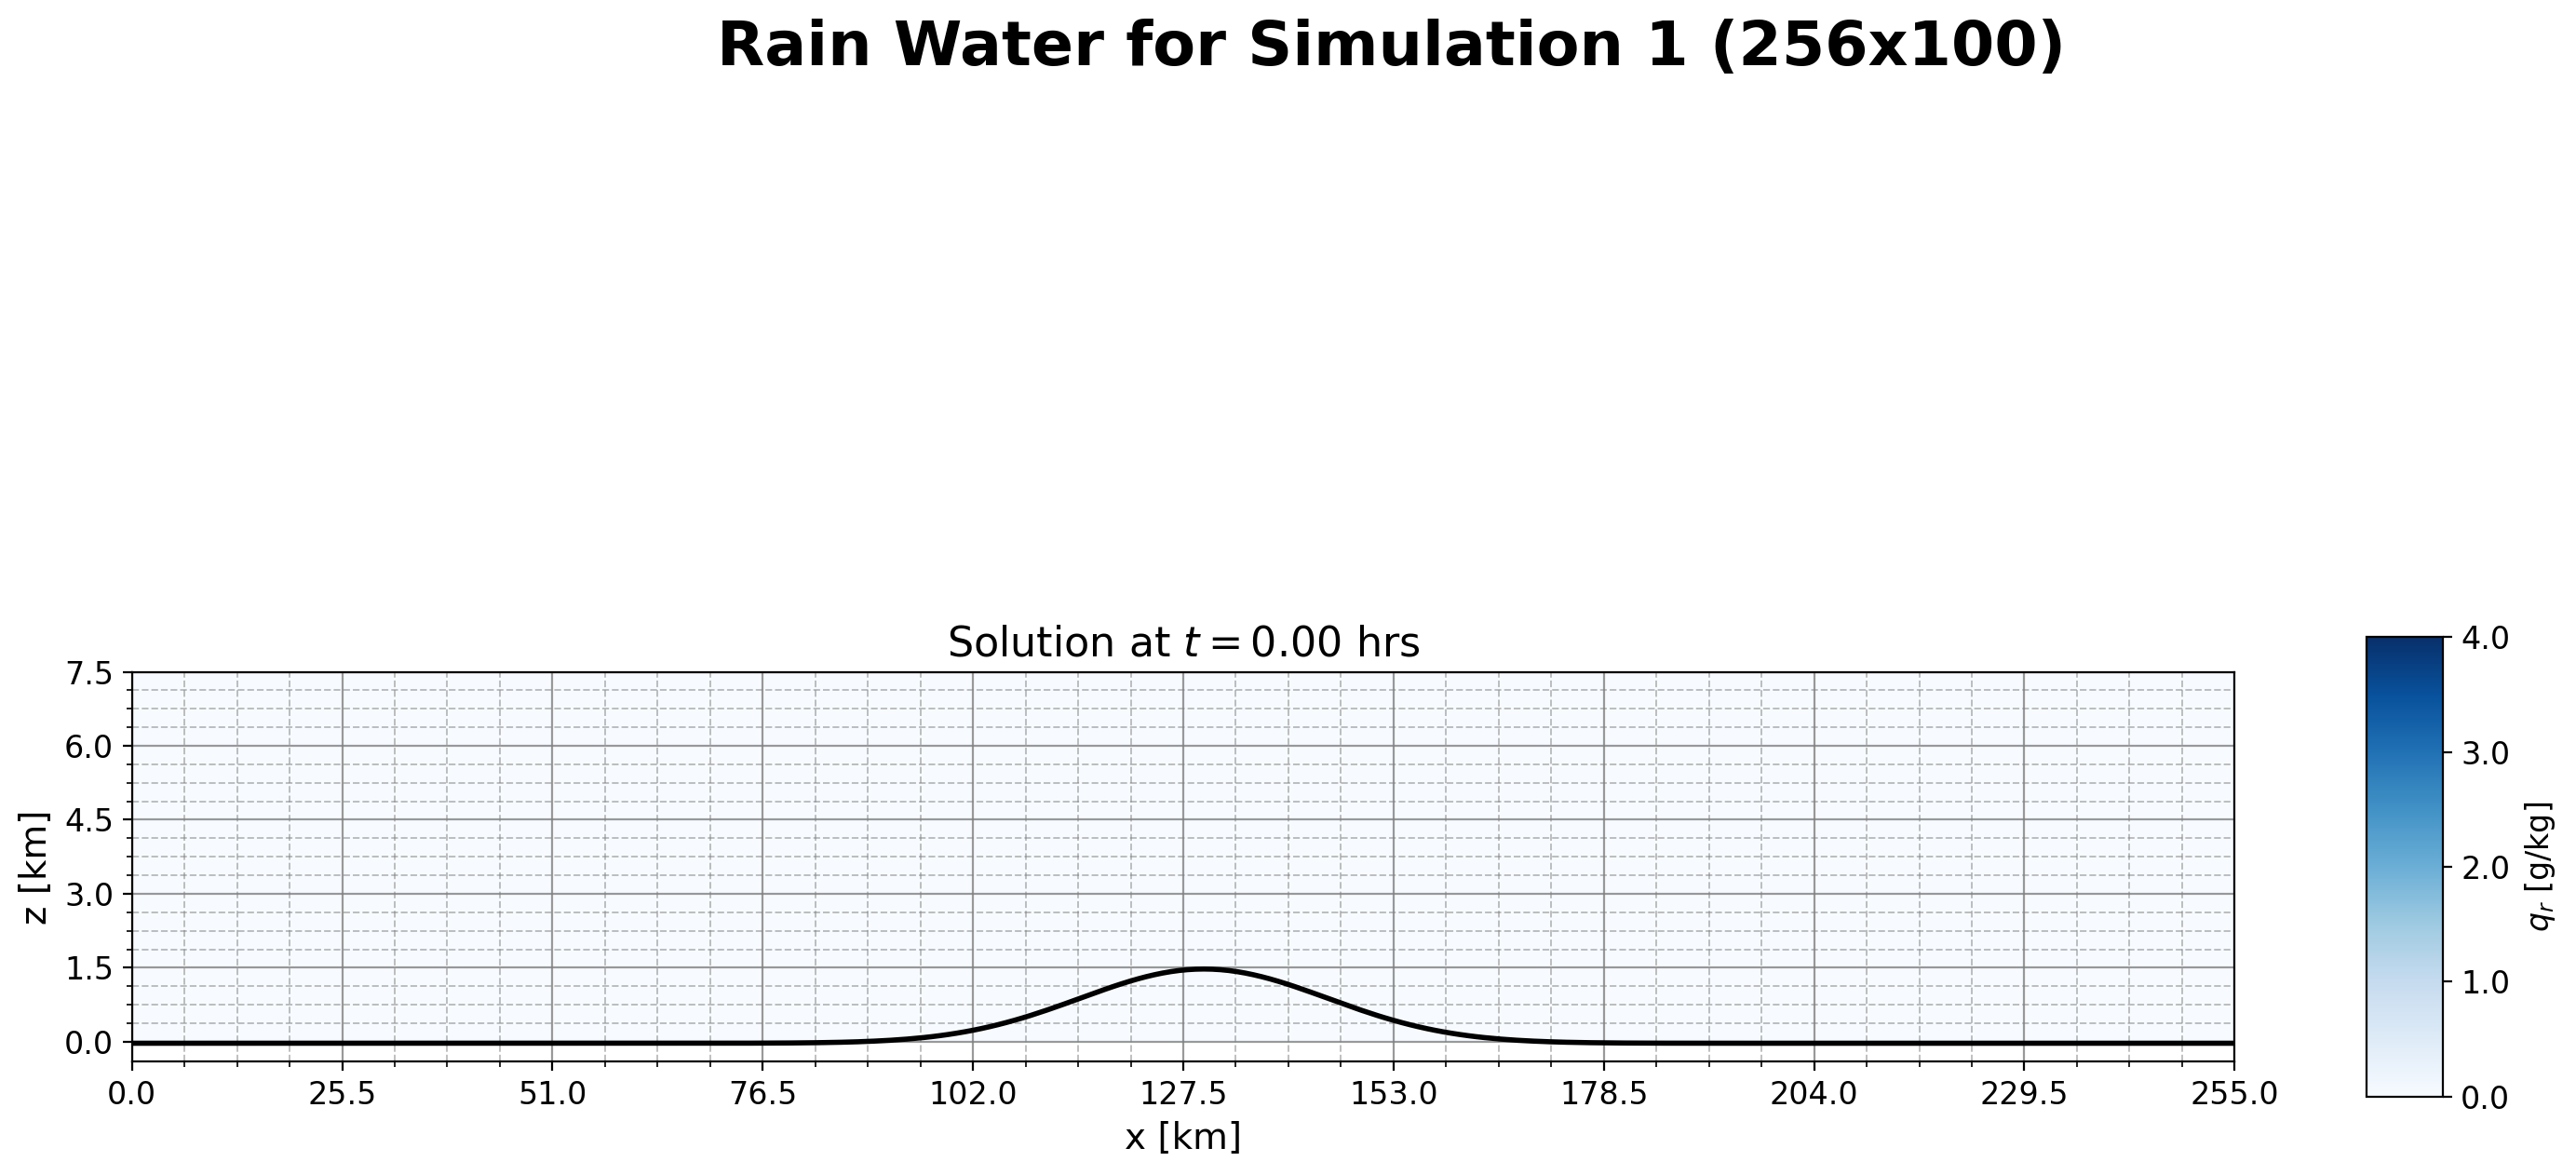

In [582]:
# rain water
vmin = 0
vmax = 0.004

sim = ["(256x100)", "(201x201)","(401x401)"]

z_cut = 125


for i in range(0,1):
    Quantity = qr_s[i][:, :, :z_cut]
    x1, y1 = x[i][:, :z_cut], z[i][:, :z_cut]

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)
    ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

    # Filled and line contours
    cf = ax.contourf(x1, y1, Quantity[0], levels=np.linspace(vmin, vmax, 25), cmap='Blues', vmin=vmin, vmax=vmax, extend='both') #RdYlBu_r

    # Labels and formatting
    ax.set_title(r"Solution at $t = $"+ f"{t_s[i][0]:.3f} sec", fontsize=16, y=1)
    plt.suptitle(f'Rain Water for Simulation {i+1} '+sim[i], fontsize=24, fontweight='bold', y=0.98)
    ax.set_xlabel('x [km]', fontsize=12)
    ax.set_ylabel('z [km]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_aspect(6, anchor='C')

    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
    ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)
     #    fig.subplots_adjust(left=0.07, right=0.93, top=0.88, bottom=0.1)


    # Colorbar
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mappable = cm.ScalarMappable(norm=norm, cmap='Blues')
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.3, aspect=6)
    cbar.set_label(f'$q_r$ [g/kg]', fontsize=12, labelpad=5)
    cbar.ax.tick_params(labelsize=12)
    formatter = FuncFormatter(lambda val, _: f"{val * 1000:.1f}")
    cbar.ax.yaxis.set_major_formatter(formatter)
    fig.tight_layout()

    def update(n):
        ax.clear()

        # Filled and black line contours
        cf = ax.contourf(x1, y1, Quantity[n], levels=np.linspace(vmin, vmax, 25), cmap='Blues', vmin=vmin, vmax=vmax, extend='both')
        ax.plot(x_line, h, zorder=20, color='black', linewidth=2)
        
        # Title and labels
        ax.set_title(r"Solution at $t = $"+ f"{t_s[i][n]/3600:.2f} hrs", fontsize=16, y=1)
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [km]', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect(6, anchor='C')

        # Ticks and grid
        ax.minorticks_on()
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
        ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
        ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
        ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
        ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

        return cf

    # Create and save animation
    ani = FuncAnimation(fig, update, frames=range(0,1801), interval=50, blit=False)

    filename = f"Mount_{i+1}_OceanMan.mp4"
    ani.save(filename, writer='ffmpeg', fps=20)
    print(f'Simulation {i+1} is complete!')

    # Display in notebook
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(filename).as_posix()}" type="video/mp4">
      Your browser does not support the video tag.</video>"""))

Simulation 1 is complete!


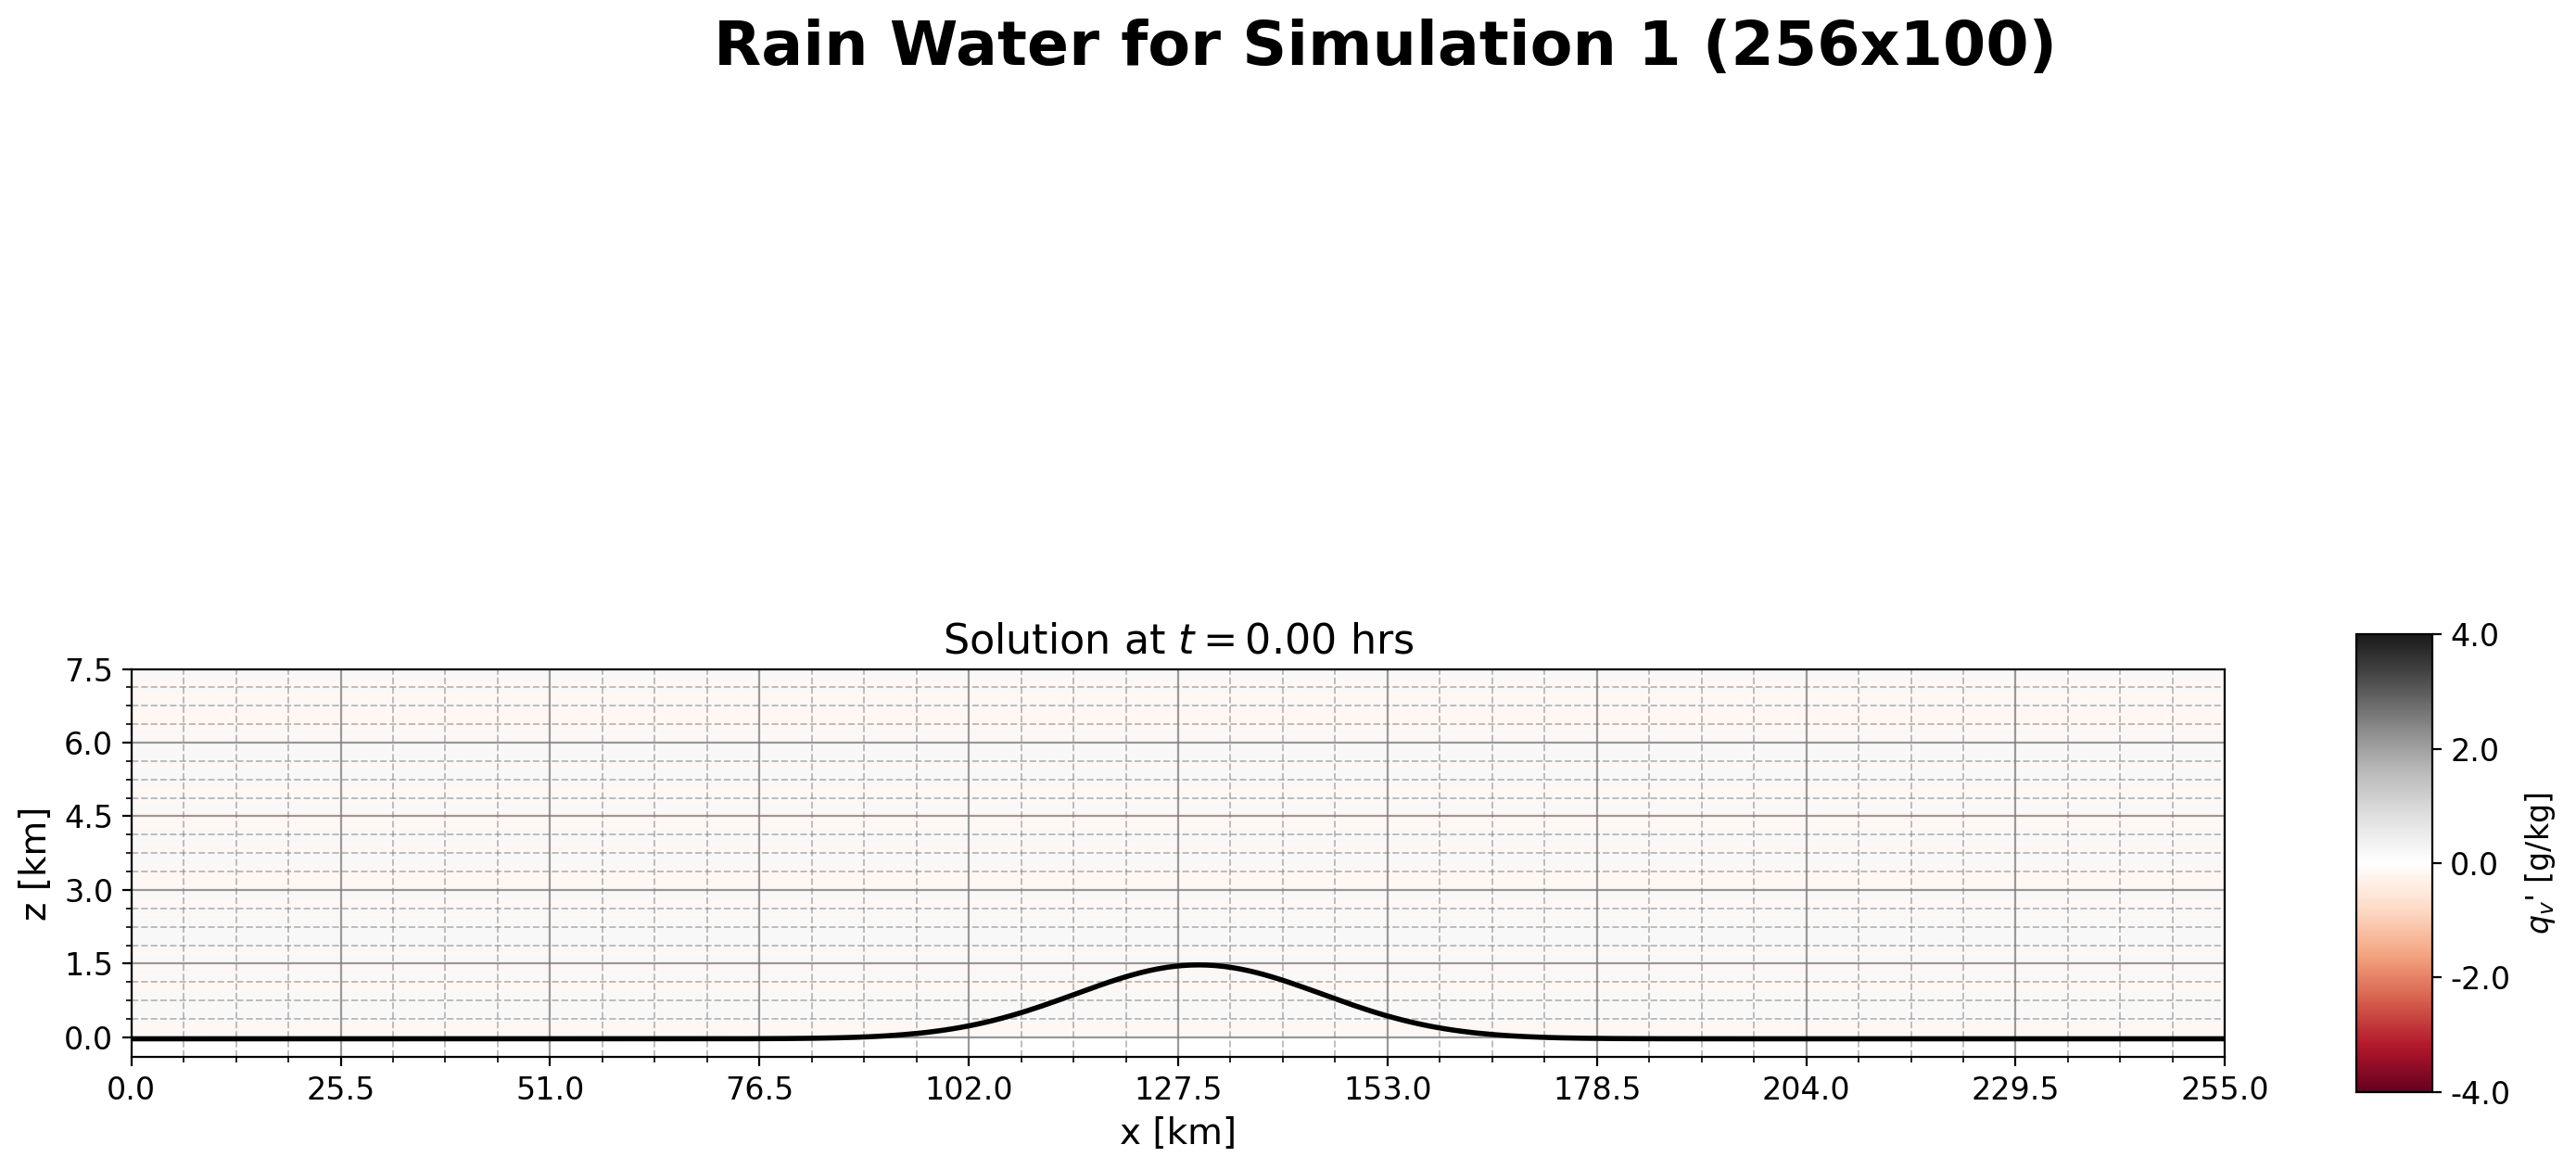

In [583]:
# vapor water pertubation from mean at that altitude
vmin = -0.004
vmax = 0.004

sim = ["(256x100)", "(201x201)","(401x401)"]

for i in range(0,1):
    Quantity = qv_s[i][:, :, :z_cut]
    x1, y1 = x[i][:, :z_cut], z[i][:, :z_cut]

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)

    # Filled and line contours
    cf = ax.contourf(x1, y1, Quantity[0]-np.mean(Quantity[0], axis=0, keepdims=True), levels=np.linspace(vmin, vmax, 25), cmap='RdGy', vmin=vmin, vmax=vmax, extend='both') #RdYlBu_r

    ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

    # Labels and formatting
    ax.set_title(r"Solution at $t = $"+ f"{t_s[i][0]:.3f} sec", fontsize=16, y=1)
    plt.suptitle(f'Rain Water for Simulation {i+1} '+sim[i], fontsize=24, fontweight='bold', y=0.98)
    ax.set_xlabel('x [km]', fontsize=12)
    ax.set_ylabel('z [km]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_aspect(6, anchor='C')

    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
    ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)
     #    fig.subplots_adjust(left=0.07, right=0.93, top=0.88, bottom=0.1)


    # Colorbar
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mappable = cm.ScalarMappable(norm=norm, cmap='RdGy')
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.3, aspect=6)
    cbar.set_label(f"$q_v$' [g/kg]", fontsize=12, labelpad=5)
    cbar.ax.tick_params(labelsize=12)
    formatter = FuncFormatter(lambda val, _: f"{val * 1000:.1f}")
    cbar.ax.yaxis.set_major_formatter(formatter)
    fig.tight_layout()

    def update(n):
        ax.clear()

        # Filled and black line contours
        cf = ax.contourf(x1, y1, Quantity[n]-np.mean(Quantity[n], axis=0, keepdims=True), levels=np.linspace(vmin, vmax, 25), cmap='RdGy', vmin=vmin, vmax=vmax, extend='both')
        ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

        # Title and labels
        ax.set_title(r"Solution at $t = $"+ f"{t_s[i][n]/3600:.2f} hrs", fontsize=16, y=1)
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [km]', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect(6, anchor='C')

        # Ticks and grid
        ax.minorticks_on()
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
        ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
        ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
        ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
        ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

        return cf

    # Create and save animation
    ani = FuncAnimation(fig, update, frames=range(0,1801), interval=50, blit=False)

    filename = f"Mount_{i+1}_VaporMan.mp4"
    ani.save(filename, writer='ffmpeg', fps=20)
    print(f'Simulation {i+1} is complete!')

    # Display in notebook
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(filename).as_posix()}" type="video/mp4">
      Your browser does not support the video tag.</video>"""))

## Conservation / Stability Plots

In [289]:
from scipy.integrate import cumulative_trapezoid
R_int_time = cumulative_trapezoid(cons_R[0], t_s[0], initial=0)

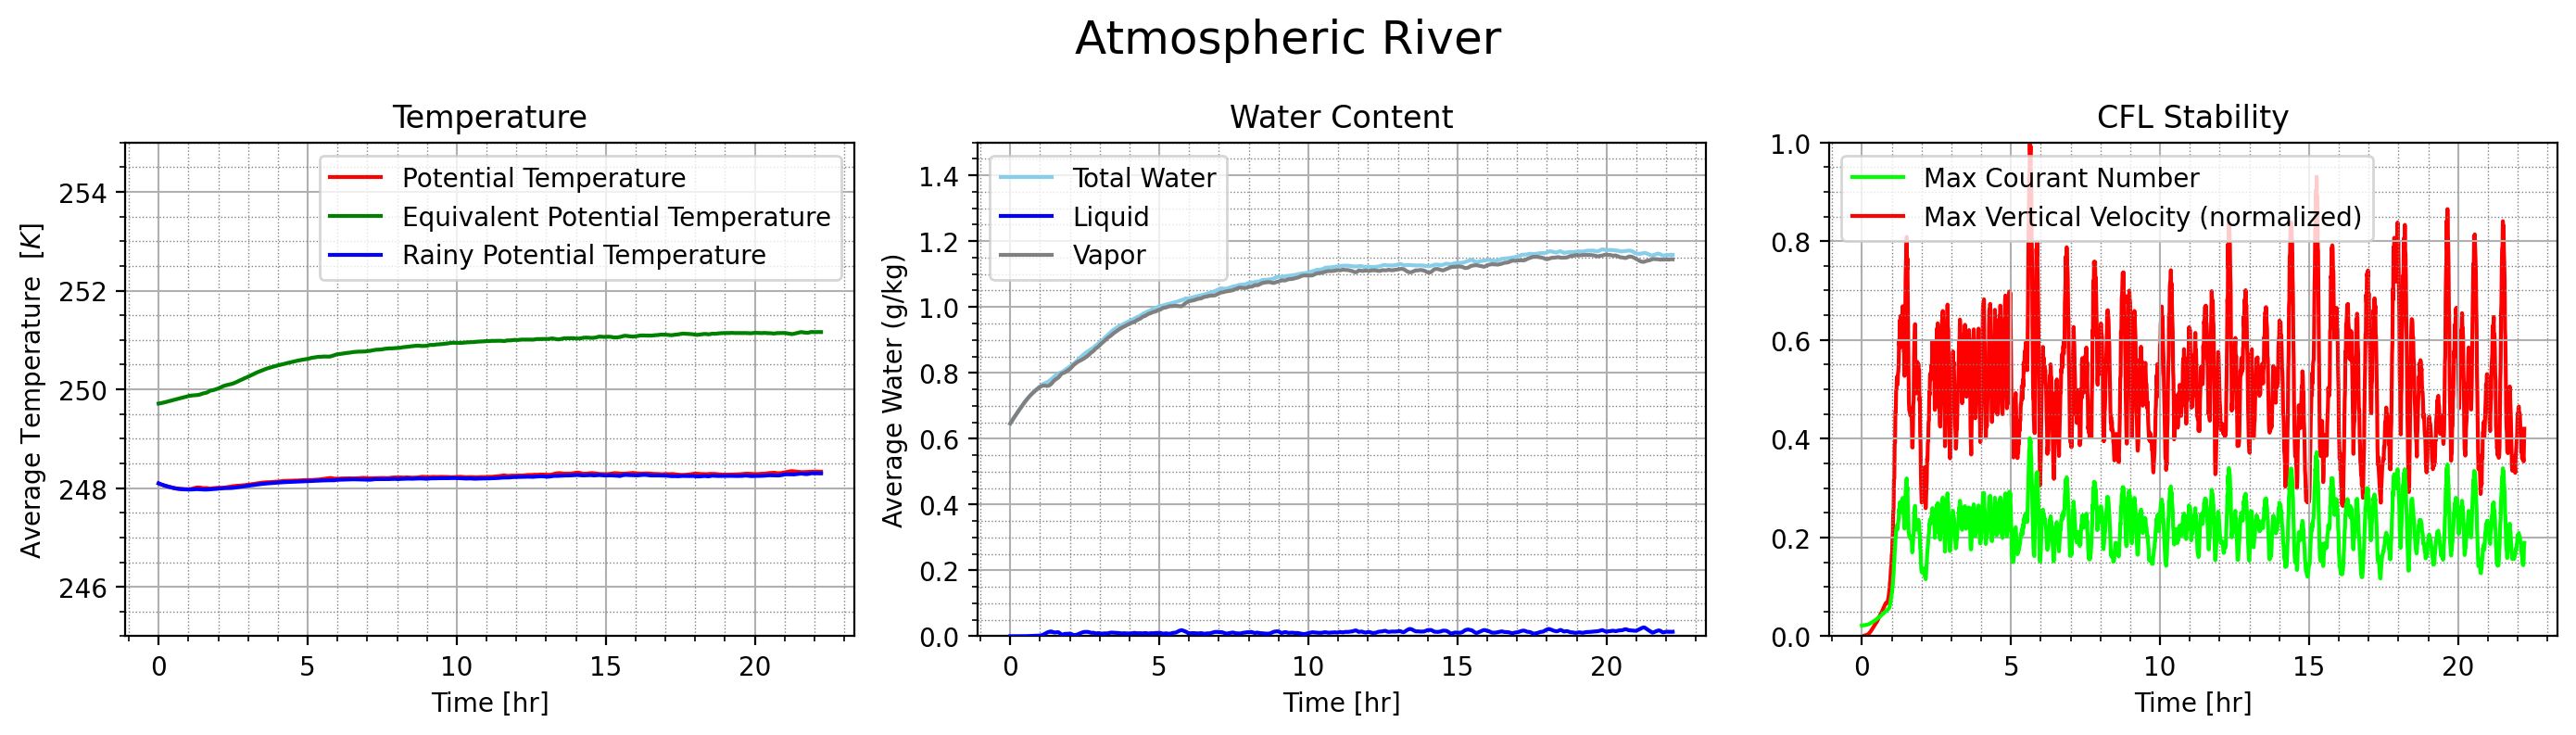

In [578]:
plt.figure(figsize=(14,4), dpi=200)
plt.subplot(1,3,1)
#plt.plot(t_s[0]/3600, temp_max[0], color='darkorange', label='Max Potential Temperature',zorder=3)
plt.plot(t_s[0]/3600, cons_pot[0]/(256000*15000), color='red', label='Potential Temperature',zorder=3)
plt.plot(t_s[0]/3600, cons_pote[0]/(256000*15000), color='green', label='Equivalent Potential Temperature',zorder=3)
plt.plot(t_s[0]/3600, cons_potr[0]/(256000*15000), color='blue', label='Rainy Potential Temperature',zorder=3)
plt.ylim(245,255)
plt.legend()
plt.xlabel('Time [hr]')
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
plt.ylabel('Average Temperature  [$K$]')
plt.title('Temperature')

plt.subplot(1,3,3)
plt.plot(t_s[0]/3600, C[0], color='lime', label='Max Courant Number',zorder=3)
plt.plot(t_s[0]/3600, w_max[0]/(np.max(w_max[0])), color='red', label='Max Vertical Velocity (normalized)',zorder=1)
plt.ylim(0,1)
plt.legend()
plt.xlabel('Time [hr]')
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
plt.title('CFL Stability')

plt.subplot(1,3,2)
plt.plot(t_s[0]/3600, cons_qt[0]*1000/(256000*15000), color='skyblue', label='Total Water',zorder=3)
plt.plot(t_s[0]/3600, cons_qr[0]*1000/(256000*15000), color='blue', label='Liquid',zorder=3)
plt.plot(t_s[0]/3600, cons_qv[0]*1000/(256000*15000), color='grey', label='Vapor',zorder=3)
plt.legend()
plt.xlabel('Time [hr]')
plt.ylim(0,1.5)
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
plt.ylabel('Average Water (g/kg)')
plt.title('Water Content')
plt.suptitle('Atmospheric River',fontsize=18)
plt.tight_layout()
plt.savefig('Mount_Stats.png', dpi=200)

In [ ]:
plt.subplot(2,2,4)
#plt.plot(t_s[0]/3600, cons_K[0]/(256000*15000), color='skyblue', label='Total Water',zorder=3)
plt.plot(t_s[0]/3600, cons_B[0]/(256000*15000), color='grey', label='Liquid',zorder=3)
plt.plot(t_s[0]/3600, R_int_time/(256000*15000), color='grey', label='Liquid',zorder=3)
plt.legend()
plt.xlabel('Time [hr]')
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
plt.ylabel('Total Water (g/kg)')
plt.title('Average Water Content')

plt.savefig('TempSer.png', dpi=200)